In [18]:
%pip install numpy
%pip install matplotlib
%pip install imageio


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
from helpers.viz import greedy_policy_from_V
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [21]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

# VI parameters
max_number_iterations = 100 # max number of value iterations
threshold = 1e-5 # stopping condition
gamma = 0.99 # discount factor

# Evaluation parameters
max_steps_in_env = 20 # used for episodic evaluation only

In [22]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)

num_states = num_rows * num_cols # number of unique states
V  = np.zeros(num_states) # initialization for V(s)
n_actions = len(ACTIONS)
for k in range(1, max_number_iterations + 1):
  V_prev = V.copy() # remember to secure the previous VI
  for curr_state in range(num_states):
    if env.is_terminal_state(curr_state): # keep value of terminal state at 0
        continue
    q_a = np.zeros(n_actions)
    for action in range(n_actions):
      for p, s_next in env.get_transition_distribution(curr_state, action): # sum across all possible next states
        # terminal state as a next state also gives no future rewards
        q_a[action] += p * (env.reward(curr_state, action, s_next) + gamma * V_prev[s_next]*(1-env.is_terminal_state(s_next))) 
    V[curr_state] = np.max(q_a)
  delta = np.max(np.abs(V - V_prev)) # find the biggest change between V and V_prev
  if delta < threshold:
    print(k)
    break

34


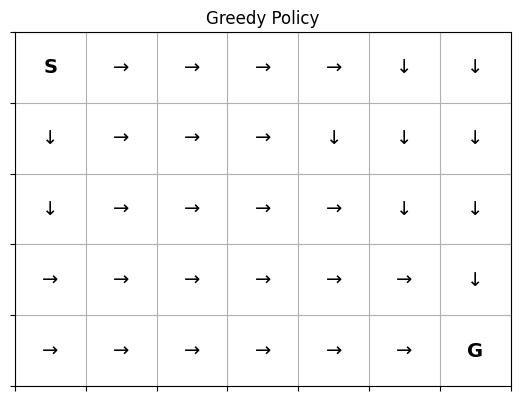

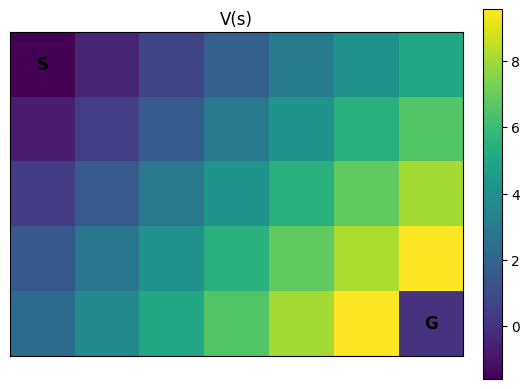

{'avg_return': -0.92, 'std_return': 1.9271, 'success_rate': 1.0, 'avg_steps': 11.92}


In [23]:
policy_plot_name = "policy_VI.png"
value_plot_name = "value_VI.png"
gif_name = "episode_VI.gif"
n_val_episodes = 50

env.reset()

# retrieve policy from V(s)
pi = greedy_policy_from_V(V, env, gamma)
# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)